# 00 pip

In [7]:
!{sys.executable} -m pip install geopandas
!{sys.executable} -m pip install rasterio
!{sys.executable} -m pip install matplotlib
!{sys.executable} -m pip install statsmodels
!{sys.executable} -m pip install matplotlib_scalebar

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


# 00 grid size from 120-1080 and 450

In [12]:
grid_sizes = list(range(120, 1080 + 1, 120))
grid_sizes.append(450)
seoul_boundary_file = r'D:\seoul\Final_data\Admin_boundary\Seoul_boundary.shp'

In [106]:
import geopandas as gpd
from shapely.geometry import box
import numpy as np
import os

seoul_boundary = gpd.read_file(seoul_boundary_file)
seoul_union = seoul_boundary.unary_union
minx, miny, maxx, maxy = seoul_boundary.total_bounds


output_dir = r'D:\seoul\grids'
os.makedirs(output_dir, exist_ok=True)

for size in grid_sizes:
    print(f"\n🟦 生成 {size}m 网格...")
    n_cols = int((maxx - minx) // size) + 1
    n_rows = int((maxy - miny) // size) + 1

    cols = [minx + i * size for i in range(n_cols)]
    rows = [miny + j * size for j in range(n_rows)]
    grid_cells = []

    for x in cols:
        for y in rows:
            grid_cells.append(box(x, y, x + size, y + size))

    grid = gpd.GeoDataFrame({'geometry': grid_cells}, crs=seoul_boundary.crs)

    # ✅ 与边界裁剪
    grid_clipped = gpd.overlay(grid, seoul_boundary, how='intersection')

    # ✅ 添加 Shape_Area 字段（单位: m²）
    grid_clipped['Shape_Area'] = grid_clipped.geometry.area

    # ✅ 输出统计信息（可选）
    print("✂️  每个格子的 Shape_Area（单位：m²）:")
    print(grid_clipped['Shape_Area'].describe())

    # ✅ 保存文件
    out_path = os.path.join(output_dir, f'grid_{size}m.shp')
    grid_clipped.to_file(out_path)
    print(f'✔ Saved: {out_path} ({len(grid_clipped)} clipped cells)')

C:\Users\owner\AppData\Local\Temp\ipykernel_19924\2017845615.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  seoul_union = seoul_boundary.unary_union



🟦 生成 120m 网格...
✂️  每个格子的 Shape_Area（单位：m²）:
count    42948.000000
mean     14091.068102
std       1782.090712
min          0.061367
25%      14400.000000
50%      14400.000000
75%      14400.000000
max      14400.000000
Name: Shape_Area, dtype: float64
✔ Saved: D:\seoul\grids\grid_120m.shp (42948 clipped cells)

🟦 生成 240m 网格...
✂️  每个格子的 Shape_Area（单位：m²）:
count    10958.000000
mean     55227.522617
std       9764.834324
min          0.141751
25%      57600.000000
50%      57600.000000
75%      57600.000000
max      57600.000000
Name: Shape_Area, dtype: float64
✔ Saved: D:\seoul\grids\grid_240m.shp (10958 clipped cells)

🟦 生成 360m 网格...
✂️  每个格子的 Shape_Area（单位：m²）:
count      4962.000000
mean     121963.561637
std       26021.428462
min          13.464673
25%      129600.000000
50%      129600.000000
75%      129600.000000
max      129600.000000
Name: Shape_Area, dtype: float64
✔ Saved: D:\seoul\grids\grid_360m.shp (4962 clipped cells)

🟦 生成 480m 网格...
✂️  每个格子的 Shape_Area（单位：m²）:
co

In [2]:
import geopandas as gpd
import os

input_dir = r'D:\seoul\grids'

for size in grid_sizes:
    shp_path = os.path.join(input_dir, f'grid_{size}m.shp')
    if not os.path.exists(shp_path):
        print(f"⚠️ 文件不存在：{shp_path}")
        continue

    # 1) 读文件
    gdf = gpd.read_file(shp_path)

    # 2) 计算最大 area
    max_area = gdf['Shape_Area'].max()

    # 3) 只保留完整格子（area == max_area）
    gdf = gdf[gdf['Shape_Area'] == max_area]

    # 5) 删除原来的各类文件，以便覆盖
    base = shp_path[:-4]  # 去掉 ".shp"
    for ext in ['.shp', '.shx', '.dbf', '.prj', '.cpg']:
        f = base + ext
        if os.path.exists(f):
            os.remove(f)

    # 6) 写回同名 shapefile
    gdf.to_file(shp_path)
    print(f"✔ 已更新：grid_{size}m.shp，保留 {len(gdf)} 个完整格子")

✔ 已更新：grid_120m.shp，保留 41088 个完整格子
✔ 已更新：grid_240m.shp，保留 10049 个完整格子
✔ 已更新：grid_360m.shp，保留 4379 个完整格子
✔ 已更新：grid_480m.shp，保留 2407 个完整格子
✔ 已更新：grid_600m.shp，保留 1514 个完整格子
✔ 已更新：grid_720m.shp，保留 1029 个完整格子
✔ 已更新：grid_840m.shp，保留 736 个完整格子
✔ 已更新：grid_960m.shp，保留 557 个完整格子
✔ 已更新：grid_1080m.shp，保留 429 个完整格子
✔ 已更新：grid_450m.shp，保留 2764 个完整格子


# 01 landsat data process and HR

In [10]:
# import os
# import rasterio
# import geopandas as gpd
# from rasterio.mask import mask
# from glob import glob
#
# def clip_rasters_with_shapefile(raster_folder, shapefile_path, output_folder):
#     # Ensure the output directory exists
#     os.makedirs(output_folder, exist_ok=True)
#
#     # Load the shapefile as a GeoDataFrame
#     nyc_shape = gpd.read_file(shapefile_path)
#
#     # Loop through each raster in the raster folder
#     for raster_path in glob(os.path.join(raster_folder, '*.tif')):
#         with rasterio.open(raster_path) as src:
#             raster_crs = src.crs
#
#             # Ensure the shapefile is in the same CRS as the raster
#             if nyc_shape.crs != raster_crs:
#                 nyc_shape = nyc_shape.to_crs(raster_crs)
#
#             # Clip the raster using the shapefile
#             out_image, out_transform = mask(src, nyc_shape.geometry, crop=True)
#
#             # Update metadata for the output raster
#             out_meta = src.meta.copy()
#             out_meta.update({
#                 "driver": "GTiff",
#                 "height": out_image.shape[1],
#                 "width": out_image.shape[2],
#                 "transform": out_transform,
#                 "crs": raster_crs  # Use the raster's CRS for the output
#             })
#
#             # Save the clipped raster to the output folder
#             output_raster_path = os.path.join(output_folder, f"clipped_{os.path.basename(raster_path)}")
#             if os.path.isdir(output_raster_path):
#                 continue
#             with rasterio.open(output_raster_path, "w", **out_meta) as dest:
#                 dest.write(out_image)
#
#             print(f"Clipped raster saved to: {output_raster_path}")

## 1 裁剪出来需要的文件

In [13]:
# # Paths to the folder and shapefile
# raster_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge'
# shp_seoul = seoul_boundary_file
# output_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped'
# os.makedirs(output_folder, exist_ok=True)
#
# clip_rasters_with_shapefile(raster_folder, shp_seoul, output_folder)

Clipped raster saved to: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_QA_PIXEL.TIF
Clipped raster saved to: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_ST_B10.TIF
Clipped raster saved to: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_QA_PIXEL.TIF
Clipped raster saved to: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_ST_B10.TIF


## 2 计算百分比

In [14]:
# import rasterio
# import numpy as np
# import os
#
# def get_sorted_dates(file_path, suffix="QA_PIXEL.TIF"):
#     # Retrieve all file names in the folder
#     file_names = os.listdir(file_path)
#
#     # Extract and collect date parts from files matching the specified suffix
#     date_parts = []
#     for file_name in file_names:
#         if file_name.endswith(suffix):
#             # Extract the date part from the file name
#             date_part = file_name.split('_')[1:-2]
#             date_parts.append(date_part)
#
#     # Sort the date parts and return as a list
#     sorted_dates = sorted(date_parts)
#
#     # Print the sorted dates
#     #print(sorted_dates)
#     for date in sorted_dates:
#         print(date)
#
#     return sorted_dates
#
# file_path = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped'
# sorted_dates = get_sorted_dates(file_path)
#
# def calculate_pixel_proportion(sorted_dates, base_folder, pixel_values=[21824, 21952]):
#     for sorted_data in sorted_dates:
#         filename = "_".join(sorted_data)
#         data_path = rf'{base_folder}\clipped_{filename}_QA_PIXEL.tif'
#
#         if not os.path.exists(data_path):
#             print(f"⚠️ 文件不存在: {data_path}")
#             continue
#
#         with rasterio.open(data_path) as src:
#             qa_pixel_data = src.read(1)
#
#         non_zero_pixels = qa_pixel_data[qa_pixel_data > 0]
#         total_non_zero_pixels = non_zero_pixels.size
#
#         unique, counts = np.unique(non_zero_pixels, return_counts=True)
#         pixel_counts = dict(zip(unique, counts))
#
#         pixel_proportions = {value: count / total_non_zero_pixels for value, count in pixel_counts.items()}
#
#         print(f"📅 {filename}:")
#         for val in pixel_values:
#             prop = pixel_proportions.get(val, 0)
#             print(f"  - 像素值 {val} 的占比: {prop:.2%}")
#         print()
#
# base_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped'
# calculate_pixel_proportion(sorted_dates, base_folder)

['LC08', 'L2SP', '116034', '20200530', '20200820', '02', 'T1']
['LC08', 'L2SP', '116034', '20200919', '20201006', '02', 'T1']
📅 LC08_L2SP_116034_20200530_20200820_02_T1:
  - 像素值 21824 的占比: 93.91%
  - 像素值 21952 的占比: 4.22%

📅 LC08_L2SP_116034_20200919_20201006_02_T1:
  - 像素值 21824 的占比: 94.64%
  - 像素值 21952 的占比: 4.85%



In [15]:
import rasterio
import numpy as np

def find_high_proportion_dates(sorted_dates, input_folder, threshold=0.80, target_value=[21824,21952] ):
    high_proportion_dates = []

    for date in sorted_dates:
        # Path to the QA_PIXEL TIFF file for the current date
        filename = "_".join(date)
        data_path = rf'{input_folder}\clipped_{filename}_QA_PIXEL.tif'

        try:
            with rasterio.open(data_path) as src:
                qa_pixel_data = src.read(1)  # Read the first band data

            # Filter for non-zero pixels
            non_zero_pixels = qa_pixel_data[qa_pixel_data > 0]
            total_non_zero_pixels = non_zero_pixels.size

            # Count unique pixel values and calculate proportions
            unique, counts = np.unique(non_zero_pixels, return_counts=True)
            pixel_counts = dict(zip(unique, counts))
            pixel_proportions = {value: count / total_non_zero_pixels for value, count in pixel_counts.items()}

            # Check the proportion of the target values
            proportion_target_value = sum(pixel_proportions.get(val, 0) for val in target_value)
            if proportion_target_value > threshold:
                high_proportion_dates.append((filename, proportion_target_value))
                print(f"{filename} pixel values {target_value} combined proportion: {proportion_target_value:.2%}")


        except FileNotFoundError:
            print(f"File not found: {data_path}")

    return high_proportion_dates

input_folder=r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped'
high_proportion_dates = find_high_proportion_dates(sorted_dates, input_folder)

# Print results
print("\nDates with high target value proportion:")
for date, proportion in high_proportion_dates:
    print(f"{date}: {proportion:.2%}")


LC08_L2SP_116034_20200530_20200820_02_T1 pixel values [21824, 21952] combined proportion: 98.13%
LC08_L2SP_116034_20200919_20201006_02_T1 pixel values [21824, 21952] combined proportion: 99.49%

Dates with high target value proportion:
LC08_L2SP_116034_20200530_20200820_02_T1: 98.13%
LC08_L2SP_116034_20200919_20201006_02_T1: 99.49%


# 用 QA数据清理B10 -> clean data

In [17]:
# import rasterio
# import numpy as np
# import os
# for date, proportion in high_proportion_dates:
#     data_workspace = r"D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped"
#     b_10_data = os.path.join(data_workspace, rf'clipped_{date}_ST_B10.tif')
#     qa_data = os.path.join(data_workspace, rf'clipped_{date}_QA_PIXEL.tif')
#     output_folder = os.path.join(data_workspace,r'clean')
#     os.makedirs(output_folder,exist_ok=True)
#
#     output_data = os.path.join(output_folder, rf'clipped_{date}_B10_cleaned.tif')
#     print("B10 Data Path:", b_10_data)
#     print("QA Data Path:", qa_data)
#     print("Output Data Path:", output_data)
#
#     # Read Band 10 and QA data
#     with rasterio.open(b_10_data) as src:
#         band10 = src.read(1).astype(float)  # Convert data to float type to support NaN
#         profile = src.profile
#
#     with rasterio.open(qa_data) as qa_src:
#         qa = qa_src.read(1)  # Read QA pixel data
#
#     # Define labels for different cloud and shadow conditions
#     label = [1, 21824, 21826, 21888, 21890, 22080, 22144, 22280, 23888, 23952, 24088, 24216, 24344, 24472, 30048, 54596, 54852, 55052]
#     print("Dilated cloud over land QA label:", label[2])
#
#     # Create a mask for clouds and shadows, filtering out cloud and shadow areas
#     valid_labels = [21824, 21952]
#     cloud_mask = ~np.isin(qa, valid_labels)  # mask 出非有效值（云、阴影、水等）
#
#
#     # Set cloud and shadow areas to 0
#     band10[cloud_mask] = 0
#
#     # Save the processed result
#     with rasterio.open(output_data, 'w', **profile) as dst:
#         dst.write(band10, 1)


B10 Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_ST_B10.tif
QA Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_QA_PIXEL.tif
Output Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned.tif
Dilated cloud over land QA label: 21826
B10 Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_ST_B10.tif
QA Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_QA_PIXEL.tif
Output Data Path: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned.tif
Dilated cloud over land QA label: 21826


# 换成shapefile

In [18]:
# import os
# import rasterio
# import geopandas as gpd
# from rasterio.features import shapes
# from shapely.geometry import shape
#
# def raster_to_shapefile(raster_files, output_folder):
#     # 确保输出目录存在
#     os.makedirs(output_folder, exist_ok=True)
#
#     for raster_file in raster_files:
#         with rasterio.open(raster_file) as src:
#             # 获取栅格的nodata值
#             nodata_value = src.nodata
#
#             # 提取栅格的形状
#             mask = src.read(1)  # 读取第一个波段的数据
#             results = shapes(mask, mask=mask != nodata_value, transform=src.transform)
#
#             # 将结果转换为 GeoDataFrame
#             shapes_list = []
#             for geom, value in results:
#                 geom = shape(geom)
#                 if geom.is_valid:
#                     shapes_list.append({"geometry": geom, "value": value})
#
#             # 创建 GeoDataFrame
#             gdf = gpd.GeoDataFrame(shapes_list, crs=src.crs)
#
#             # 输出 Shapefile 文件路径
#             output_shapefile = os.path.join(output_folder, os.path.basename(raster_file).replace('.tif', '.shp'))
#
#             # 保存为 Shapefile
#             gdf.to_file(output_shapefile)
#
#             print(f"栅格已转换为 Shapefile 并保存到: {output_shapefile}")
#
# # 输入的栅格文件路径
# normal_files = [
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned.tif'
# ]
# extreme_files = [
#
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned.tif'
# ]
#
# # 合并所有栅格文件
# all_raster_files = normal_files + extreme_files
#
# # 输出文件夹路径
# output_shapefile_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles'
# os.makedirs(output_shapefile_folder, exist_ok=True)
#
# # 转换栅格文件为 Shapefile
# raster_to_shapefile(all_raster_files, output_shapefile_folder)

KeyboardInterrupt: 

# 得到fid的shape文件

In [2]:
# import geopandas as gpd
# import pandas as pd
# import os
# import glob
#
# def fast_clip_and_assign_fid(input_shp, clip_shp, output_shp):
#     print(f"📂 加载输入数据：{input_shp}")
#     input_gdf = gpd.read_file(input_shp)
#     clip_gdf = gpd.read_file(clip_shp)
#
#     # 确保 CRS 一致
#     if input_gdf.crs != clip_gdf.crs:
#         input_gdf = input_gdf.to_crs(clip_gdf.crs)
#
#     # 在裁剪前先加上 city_id 字段
#     clip_gdf = clip_gdf.reset_index().rename(columns={'index': 'city_id'})
#
#     print("✂️ 正在执行 overlay 精准裁剪...")
#     try:
#         clipped = gpd.overlay(input_gdf, clip_gdf[['city_id', 'geometry']], how='intersection', keep_geom_type=False)
#     except Exception as e:
#         print(f"❌ Overlay 错误: {e}")
#         return
#
#     # 保存结果
#     os.makedirs(os.path.dirname(output_shp), exist_ok=True)
#     clipped.to_file(output_shp, driver='ESRI Shapefile')
#     print(f"✅ 已保存: {output_shp}")
#
# # 输入的栅格转 Shapefile 路径（假设已经将其转化为 Shapefile）
# shapefile_files = [
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned.shp',
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned.shp'
# ]
#
# grid_folder = r'D:\seoul\grids'
# # 输出文件夹路径
# output_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid'
# # 遍历所有 grid shapefile
# for grid_file in os.listdir(grid_folder):
#     if grid_file.endswith('.shp'):
#         grid_path = os.path.join(grid_folder, grid_file)
#
#         for input_shp in shapefile_files:
#             input_name = os.path.splitext(os.path.basename(input_shp))[0]
#             grid_name = os.path.splitext(os.path.basename(grid_file))[0]
#             output_name = f'{input_name}_clipped_by_{grid_name}_with_fid.shp'
#             output_shp = os.path.join(output_folder, output_name)
#             if os.path.exists(output_shp):
#                 print(f"⏩ 已存在，跳过: {output_shp}")
#                 continue
#             fast_clip_and_assign_fid(input_shp, grid_path, output_shp)

⏩ 已存在，跳过: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_clipped_by_grid_1080m_with_fid.shp
⏩ 已存在，跳过: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_clipped_by_grid_1080m_with_fid.shp
⏩ 已存在，跳过: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_clipped_by_grid_120m_with_fid.shp
⏩ 已存在，跳过: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_clipped_by_grid_120m_with_fid.shp
⏩ 已存在，跳过: D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_clipped_by_grid_240m_with_fid.sh

# 先将数据洗成摄氏度 bt -> lst

In [6]:
# import rasterio
# import numpy as np
# import os
#
# def calculate_lst(input_files, output_dir, multiplier=0.00341802, add_constant=149.0, nodata_value=-9999):
#     """
#     Calculate Land Surface Temperature (LST) from a list of raster files and save the output.
#
#     Args:
#         input_files (list): List of paths to input raster files.
#         output_dir (str): Directory to save the output raster files.
#         multiplier (float): Multiplication factor for converting to temperature.
#         add_constant (float): Additive constant for converting to temperature.
#         nodata_value (float): Value to use for no-data in the output files.
#     """
#     # Ensure the output directory exists
#     os.makedirs(output_dir, exist_ok=True)
#
#     for input_file in input_files:
#         with rasterio.open(input_file) as src:
#             # Read the first band and convert to float
#             band_data = src.read(1).astype(float)
#             profile = src.profile
#
#         # Replace values <= 0 with NaN
#         band_data[band_data <= 0] = np.nan
#
#         # Calculate brightness temperature (BT)
#         lst_kelvin = (band_data * multiplier) + add_constant
#
#         # Convert to Celsius
#         lst_celsius = lst_kelvin - 273.15
#
#         # Replace NaN values with the nodata value
#         lst_celsius[np.isnan(lst_celsius)] = nodata_value
#
#         # Update profile for the output file
#         profile.update({
#             'dtype': 'float32',
#             'count': 1,
#             'nodata': nodata_value
#         })
#
#         # Generate a short output file name
#         base_name = os.path.basename(input_file).split('.')[0]
#         output_file = os.path.join(output_dir, f"{base_name}_LST.tif")
#
#         # Save the LST raster
#         with rasterio.open(output_file, 'w', **profile) as dst:
#             dst.write(lst_celsius, 1)
#
#         print(f"LST saved to: {output_file}")
#
#
# # 输入的栅格文件路径
# normal_files = [
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned.tif'
# ]
# extreme_files = [
#     r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\clean\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned.tif'
# ]
#
# # 输出目录
# output_dir_normal = r'D:\seoul\Final_data\landsat_final\data\normal_heat_day_lst'
# output_dir_extreme = r'D:\seoul\Final_data\landsat_final\data\extreme_heat_day_lst'
#
# # 计算并保存 LST
# calculate_lst(normal_files, output_dir_normal)
# calculate_lst(extreme_files, output_dir_extreme)

LST saved to: D:\seoul\Final_data\landsat_final\data\normal_heat_day_lst\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_LST.tif
LST saved to: D:\seoul\Final_data\landsat_final\data\extreme_heat_day_lst\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_LST.tif


# 相减，然后得到HR map

In [7]:
import rasterio
import numpy as np
import os

def calculate_heat_resilience(normal_files, extreme_files, output_dir, nodata_value=-9999):
    os.makedirs(output_dir, exist_ok=True)

    if len(normal_files) != len(extreme_files):
        raise ValueError("Number of normal and extreme files must be the same.")

    for normal_file, extreme_file in zip(normal_files, extreme_files):
        with rasterio.open(normal_file) as normal_src, rasterio.open(extreme_file) as extreme_src:
            normal_data = normal_src.read(1).astype(float)
            extreme_data = extreme_src.read(1).astype(float)

            if normal_data.shape != extreme_data.shape:
                raise ValueError(f"Dimension mismatch between {normal_file} and {extreme_file}.")

            # 强制处理 nodata
            if normal_src.nodata is not None:
                normal_data[normal_data == normal_src.nodata] = np.nan
            else:
                normal_data[normal_data == nodata_value] = np.nan

            if extreme_src.nodata is not None:
                extreme_data[extreme_data == extreme_src.nodata] = np.nan
            else:
                extreme_data[extreme_data == nodata_value] = np.nan

            # 差值
            heat_resilience = normal_data - extreme_data

            # 打印调试
            print(f"\n📁 Processing: {os.path.basename(normal_file)} vs {os.path.basename(extreme_file)}")
            print("🔹 First 10 values from normal_data (non-NaN):", normal_data[~np.isnan(normal_data)].flatten()[:10])
            print("🔹 First 10 values from extreme_data (non-NaN):", extreme_data[~np.isnan(extreme_data)].flatten()[:10])
            print("🔸 First 10 values from heat_resilience (non-NaN):", heat_resilience[~np.isnan(heat_resilience)].flatten()[:10])

            # 替换 NaN 为 nodata
            heat_resilience[np.isnan(heat_resilience)] = nodata_value

            profile = normal_src.profile
            profile.update({
                'dtype': 'float32',
                'nodata': nodata_value
            })

            year = os.path.basename(normal_file).split('_')[4][:4]
            output_file = os.path.join(output_dir, f"{year}_heat_resilience.tif")

            with rasterio.open(output_file, 'w', **profile) as dst:
                dst.write(heat_resilience.astype('float32'), 1)

            print(f"✅ Heat resilience raster saved to: {output_file}")




# 输入的栅格文件路径
normal_files = [
    r'D:\seoul\Final_data\landsat_final\data\normal_heat_day_lst\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_LST.tif'
]
extreme_files = [
    r'D:\seoul\Final_data\landsat_final\data\extreme_heat_day_lst\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_LST.tif'
]

# 输出目录
output_dir = r'D:\seoul\Final_data\landsat_final\data\heat_resilience'

# 计算并保存 heat resilience
calculate_heat_resilience(normal_files, extreme_files, output_dir, nodata_value=-9999)


📁 Processing: clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_LST.tif vs clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_LST.tif
🔹 First 10 values from normal_data (non-NaN): [22.07631302 22.79067993 22.37709999 22.72915459 22.42153358 23.30680084
 23.11539078 23.31705475 23.60074997 23.68278313]
🔹 First 10 values from extreme_data (non-NaN): [26.02754402 26.52999306 25.89424133 26.16084671 26.15401077 26.85128784
 26.57101059 26.64962387 26.75558281 26.70431328]
🔸 First 10 values from heat_resilience (non-NaN): [-3.951231   -3.73931313 -3.51714134 -3.43169212 -3.73247719 -3.544487
 -3.45561981 -3.33256912 -3.15483284 -3.02153015]
✅ Heat resilience raster saved to: D:\seoul\Final_data\landsat_final\data\heat_resilience\2020_heat_resilience.tif


# 计算面积和占比

In [3]:
# import geopandas as gpd
# import os
# import pandas as pd
# from concurrent.futures import ThreadPoolExecutor
# def add_lst_ratio_within_only(clipped_gdf, city_path, output_path):
#     # ✅ STEP 1: 读取 grid 文件（即 city_gdf），用其 CRS 作为标准
#     city_gdf = gpd.read_file(city_path)
#     target_crs = city_gdf.crs  # ⬅️ 使用它为主
#     clipped = clipped_gdf.to_crs(target_crs)
#     city_gdf = city_gdf.to_crs(target_crs)
#
#     # ✅ STEP 2: 创建 city_id 和 Shape_Area
#     city_gdf = city_gdf.reset_index(drop=True)
#     city_gdf['city_id'] = city_gdf.index
#     # city_gdf['Shape_Area'] = city_gdf.geometry.area
#     city_gdf['lst'] = 0.0  # 初始化
#
#     # ✅ STEP 3: 找出每个 grid 内完全包含的 clipped polygon
#     for idx, row in city_gdf.iterrows():
#         grid_geom = row.geometry
#         inside = clipped[clipped.within(grid_geom)]
#         if not inside.empty:
#             area_sum = inside.geometry.area.sum()
#             city_gdf.at[idx, 'lst'] = area_sum
#
#     # ✅ STEP 4: 计算 lst_ratio
#     city_gdf['lst_ratio'] = city_gdf['lst'] / city_gdf['Shape_Area']
#
#     # ✅ STEP 5: 导出为 ITRF_2000_UTM_K
#     itrf_proj = (
#         '+proj=tmerc +lat_0=38 +lon_0=127.5 '
#         '+k=0.9996 +x_0=1000000 +y_0=2000000 '
#         '+ellps=GRS80 +units=m +no_defs'
#     )
#     city_gdf_final = city_gdf.to_crs(itrf_proj)
#     city_gdf_final.to_file(output_path, driver='ESRI Shapefile')
#
#     print(f"✅ 完全包含统计完成并保存: {output_path}")
#
#
#
#
# # === 设置路径 ===
# # 所有 clipped shapefiles（一个 per grid）
# clipped_folder = r'D:\seoul\Final_data\landsat_final\data\landsat8_data_merge_clipped\shapefiles_clipped_with_fid'
# clipped_files = [f for f in os.listdir(clipped_folder) if f.endswith('.shp')]
#
# # 所有 grid shapefiles
# grid_folder = r'D:\seoul\grids'
# grid_files = [f for f in os.listdir(grid_folder) if f.endswith('.shp')]
#
# # 输出文件夹
# output_folder = r'D:\seoul\grids\city_ratio_outputs'
# os.makedirs(output_folder, exist_ok=True)
#
# def process_pair(grid_file):
#     try:
#         grid_name = os.path.splitext(grid_file)[0]
#         grid_path = os.path.join(grid_folder, grid_file)
#
#         matched_clipped = [
#             f for f in clipped_files if grid_name in f
#         ]
#
#         if not matched_clipped:
#             print(f"⚠️ 找不到与 {grid_file} 匹配的 clipped 文件")
#             return
#
#         clipped_path = os.path.join(clipped_folder, matched_clipped[0])
#         clipped_gdf = gpd.read_file(clipped_path)
#         clipped_gdf = clipped_gdf.reset_index(drop=True)
#         clipped_gdf['city_id'] = clipped_gdf['FID'] if 'FID' in clipped_gdf.columns else clipped_gdf.index
#
#         output_path = os.path.join(output_folder, f'city2020_lst_ratio_{grid_name}.shp')
#         if os.path.exists(output_path):
#             print(f"⏩ 已存在，跳过: {output_path}")
#             return
#
#         add_lst_ratio_within_only(clipped_gdf, grid_path, output_path)
#
#     except Exception as e:
#         print(f"❌ 处理 {grid_file} 失败: {e}")
#
# # 🚀 并行处理
# print("🚀 开始批量匹配 grid ↔ clipped...")
# with ThreadPoolExecutor(max_workers=4) as executor:
#     executor.map(process_pair, grid_files)

🚀 开始批量匹配 grid ↔ clipped...
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_1080m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_360m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_240m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_600m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_480m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_120m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_840m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_960m.shp
⏩ 已存在，跳过: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_720m.shp
✅ 完全包含统计完成并保存: D:\seoul\grids\city_ratio_outputs\city2020_lst_ratio_grid_450m.shp


# *** 得到HR lst temperature 在extreme heat & normal heat & heat reslience 的数据

In [5]:
# import os
# import rasterio
# import numpy as np
# import geopandas as gpd
# from rasterio.mask import mask
# from shapely.geometry import mapping
#
# def calculate_polygon_means(raster_path, vector_path):
#     """
#     根据矢量多边形计算栅格的平均值。
#     :param raster_path: 栅格文件路径。
#     :param vector_path: 矢量文件路径。
#     :return: 列名（基于日期）和对应的多边形平均值列表。
#     """
#     try:
#         # 提取日期部分作为列名
#         filename = os.path.basename(raster_path)
#         date_str = filename.split('_')[2]  # 提取类似 '20170730' 的部分
#
#         # 打开矢量文件
#         vector = gpd.read_file(vector_path)
#
#         # 打开栅格文件
#         with rasterio.open(raster_path) as raster:
#             raster_crs = raster.crs
#
#             # 矢量文件需要投影到栅格的 CRS
#             if vector.crs != raster_crs:
#                 vector = vector.to_crs(raster_crs)
#                 print(f"Reprojected vector CRS to match raster CRS.")
#
#             # 用于存储每个多边形的平均值
#             mean_values = []
#
#             # 遍历每个多边形
#             for idx, row in vector.iterrows():
#                 geom = row['geometry']
#                 # 使用多边形裁剪栅格
#                 out_image, out_transform = mask(raster, [mapping(geom)], crop=True, all_touched=True)
#
#
#                 # 如果裁剪区域无数据，赋值为 NaN
#                 if out_image.size == 0:
#                     mean_values.append(np.nan)
#                 else:
#                     data = out_image[0]  # 获取第一波段
#                     # 计算平均值，忽略无效值（如 0 或 NaN）
#                     mean_val = np.nanmean(data[data != raster.nodata])
#                     mean_values.append(mean_val)
#
#             return date_str, mean_values
#
#     except Exception as e:
#         print(f"Error processing file {raster_path}: {e}")
#         return None, []
#
# # 主函数：处理多个栅格文件并保存到单个文件
# def process_rasters_to_single_file(raster_files, vector_path, output_path, group_name, year):
#     """
#     处理多个栅格文件，将结果添加为矢量文件的新列。
#     :param raster_files: 栅格文件路径列表。
#     :param vector_path: 矢量文件路径。
#     :param output_path: 输出矢量文件路径。
#     :param group_name: 当前组的名称（如 normal、extreme 等）。
#     :param year: 对应的年份列表。
#     """
#     try:
#         # 打开矢量文件
#         vector = gpd.read_file(vector_path)
#
#         # 遍历栅格文件并计算每个多边形的平均值
#         for idx, raster_file in enumerate(raster_files):
#             date_str, mean_values = calculate_polygon_means(raster_file, vector_path)
#             if date_str and mean_values:
#                 # 添加新列到矢量文件，列名为 group_name_年份
#                 column_name = f"{group_name}_{year[idx]}"
#                 vector[column_name] = mean_values
#                 print(f"Added column: {column_name}")
#
#         # 保存更新后的矢量文件
#         vector.to_file(output_path)
#         print(f"Saved updated vector file to: {output_path}")
#
#     except Exception as e:
#         print(f"Error processing rasters for group {group_name}: {e}")
#
#
# # 主脚本
# input_folder = r'D:\seoul\grids\city_ratio_outputs'
# output_folder = r'D:\seoul\grids\lst_map'
# os.makedirs(output_folder, exist_ok=True)
#
# # 输入的栅格文件路径
# normal_files = [
#     r'D:\seoul\Final_data\landsat_final\data\normal_heat_day_lst\clipped_LC08_L2SP_116034_20200919_20201006_02_T1_B10_cleaned_LST.tif'
# ]
# extreme_files = [
#     r'D:\seoul\Final_data\landsat_final\data\extreme_heat_day_lst\clipped_LC08_L2SP_116034_20200530_20200820_02_T1_B10_cleaned_LST.tif'
# ]
# hr_files = [
#     r'D:\seoul\Final_data\landsat_final\data\heat_resilience\2020_heat_resilience.tif'
# ]
#
# # 文件列表与名称的映射
# file_groups = [normal_files, extreme_files, hr_files]
# group_names = ['nor', 'ext', 'hr']
# years =[[2020],[2020],[2020]]
#
# for filename in os.listdir(input_folder):
#     if filename.endswith('.shp'):
#         input_path = os.path.join(input_folder, filename)
#         output_path = os.path.join(output_folder, filename)
#
#         # 初始化矢量文件
#         final_vector = gpd.read_file(input_path)
#
#         # 循环处理文件
#         for i in range(len(file_groups)):
#             group_files = file_groups[i]  # 当前组的文件列表
#             group_name = group_names[i]  # 当前组的名称
#             print(f"Processing {group_name} files...")  # 可选：打印当前处理的文件组
#             for idx, raster_file in enumerate(group_files):
#                 # 获取单个栅格文件的平均值
#                 date_str, mean_values = calculate_polygon_means(raster_file, input_path)
#                 if date_str and mean_values:
#                     column_name = f"{group_name}_{years[i][idx]}"
#                     final_vector[column_name] = mean_values
#                     print(f"Added column: {column_name}")
#         if os.path.exists(output_path):
#             print(f"⏩ 已存在，跳过: {output_path}")
#             continue
#         # 保存最终结果
#         final_vector.to_file(output_path)
#         print(f"Saved final vector file to: {output_path}")

Processing nor files...
Reprojected vector CRS to match raster CRS.
Added column: nor_2020
Processing ext files...
Reprojected vector CRS to match raster CRS.
Added column: ext_2020
Processing hr files...
Reprojected vector CRS to match raster CRS.


C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])


Added column: hr_2020
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m.shp
Processing nor files...
Reprojected vector CRS to match raster CRS.


C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: Runt

Added column: nor_2020
Processing ext files...
Reprojected vector CRS to match raster CRS.


...

C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])


Added column: ext_2020
Processing hr files...
Reprojected vector CRS to match raster CRS.


C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])
C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])


Added column: hr_2020
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_960m.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\1708021560.py:48: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data[data != raster.nodata])


In [11]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import cm
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib.patches import FancyArrow
import os
for i in grid_sizes: #range(120,1200,120):
    # 读取 shapefile
    shp_path = rf'D:\seoul\grids\lst_map\city2020_lst_ratio_grid_{i}m.shp'
    gdf = gpd.read_file(shp_path)

    # 提取数据列
    nor = gdf['nor_2020']
    ext = gdf['ext_2020']
    hr = gdf['hr_2020']

    # 设置色带范围
    lst_vmin = min(nor.min(), ext.min())
    lst_vmax = max(nor.max(), ext.max())

    # 创建图像和子图
    fig, axes = plt.subplots(1, 3, figsize=(22, 10))

    # 配色方案
    lst_cmap = 'RdYlBu_r'
    hr_cmap = 'RdYlBu'

    # 绘制 LST 图
    gdf.plot(column='nor_2020', cmap=lst_cmap, linewidth=0.2, edgecolor='black',  ax=axes[0], vmin=lst_vmin, vmax=lst_vmax)
    axes[0].set_title(f'Regular LST (grid {i}m)')
    axes[0].axis('off')
    scalebar = ScaleBar(1, units="m", location='lower right')  # 假设坐标单位为米
    axes[0].add_artist(scalebar)
    gdf.plot(column='ext_2020', cmap=lst_cmap, linewidth=0.2, edgecolor='black',  ax=axes[1], vmin=lst_vmin, vmax=lst_vmax)
    axes[1].set_title(f'Extreme LST (grid {i}m)')
    axes[1].axis('off')
    scalebar = ScaleBar(1, units="m", location='lower right')  # 假设坐标单位为米
    axes[1].add_artist(scalebar)
    # 绘制 Heat Resilience
    gdf.plot(column='hr_2020', cmap=hr_cmap, linewidth=0.2, edgecolor='black',  ax=axes[2], vmin=hr.min(), vmax=hr.max())
    axes[2].set_title(f'Heat Resilience (grid {i}m)')
    axes[2].axis('off')
    scalebar = ScaleBar(1, units="m", location='lower right')  # 假设坐标单位为米
    axes[2].add_artist(scalebar)


    arrow = FancyArrow(0.9, 0.9, 0, 0.1, width=0.02, transform=axes[2].transAxes,
                       color='black', length_includes_head=True)
    axes[2].add_patch(arrow)
    axes[2].text(0.9, 0.81, 'N', transform=axes[2].transAxes,
                 ha='center', va='bottom', fontsize=12, fontweight='bold')

    # 添加两个 colorbar
    fig.subplots_adjust(bottom=0.15)

    # colorbar 1：LST 色卡
    cax1 = fig.add_axes([0.25, 0.25, 0.25, 0.015])
    sm1 = cm.ScalarMappable(cmap=lst_cmap, norm=mcolors.Normalize(vmin=lst_vmin, vmax=lst_vmax))
    sm1._A = []
    cb1 = fig.colorbar(sm1, cax=cax1, orientation='horizontal')
    cb1.set_label('LST (°C)', fontsize=12)

    # colorbar 2：HR 色卡
    cax2 = fig.add_axes([0.75, 0.25, 0.1, 0.015])
    sm2 = cm.ScalarMappable(cmap=hr_cmap, norm=mcolors.Normalize(vmin=hr.min(), vmax=hr.max()))
    sm2._A = []
    cb2 = fig.colorbar(sm2, cax=cax2, orientation='horizontal')
    cb2.set_label('Heat Resilience (°C)', fontsize=12)

    # 保存图像（建议保存为高分辨率 PNG）
    output_path = rf'D:\seoul\grids\lst_map\figures\lst_map_{i}m.png'
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"✅ Saved: {output_path}")
    plt.close()  # 关闭图像窗口，释放内存
    plt.show()

✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_120m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_240m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_360m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_480m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_600m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_720m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_840m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_960m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_1080m.png
✅ Saved: D:\seoul\grids\lst_map\figures\lst_map_450m.png


# 【图】 给初始网格出图

In [9]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 首尔行政边界
shp_seoul = r'D:\seoul\Final_data\Admin_boundary\Seoul_boundary.shp'
gdf_seoul = gpd.read_file(shp_seoul)

# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\figures\grids_gray'
os.makedirs(output_folder, exist_ok=True)

for i in grid_sizes:
    shp_path = rf'D:\seoul\grids\grid_{i}m.shp'
    gdf = gpd.read_file(shp_path)

    # 如果两者 CRS 不一致，投影到相同坐标系
    if gdf.crs != gdf_seoul.crs:
        gdf_seoul = gdf_seoul.to_crs(gdf.crs)

    fig, ax = plt.subplots(figsize=(8, 8))
    # 再叠加边界线
    gdf_seoul.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8)
    # 先画格网
    gdf.plot(ax=ax, facecolor='lightgray', edgecolor='gray', linewidth=0.3)


    ax.set_title(f'Grid Size: {i}m', fontsize=14)
    ax.axis('off')

    output_path = os.path.join(output_folder, f'grid_{i}m_gray.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"✅ Saved: {output_path}")


✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_120m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_240m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_360m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_480m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_600m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_720m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_840m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_960m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_1080m_gray.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_gray\grid_450m_gray.png


# 02 building - BRC & BHV

In [1]:
import geopandas as gpd
import os
import numpy as np
from concurrent.futures import ThreadPoolExecutor

# === 文件路径 ===
building_file = r'D:\seoul\Final_data\skyviewfactor\svf calculation_qgis\bldg_bd_merge.shp'
input_folder = r'D:\seoul\grids\lst_map'
output_folder = input_folder

# ✅ 读取一次 building 数据
print("🔄 正在读取建筑数据...")
building_gdf = gpd.read_file(building_file)

def add_building_stats(building_gdf, grid_path, output_path):
    # 使用 grid 的 CRS 作为标准
    grid_gdf = gpd.read_file(grid_path)
    target_crs = grid_gdf.crs
    building_proj = building_gdf.to_crs(target_crs)
    grid_gdf = grid_gdf.to_crs(target_crs)

    # 初始化字段
    grid_gdf = grid_gdf.reset_index(drop=True)
    grid_gdf['grid_id'] = grid_gdf.index
    grid_gdf['BCR(%)'] = 0.0
    grid_gdf['BHV'] = 0.0

    # 逐个格子处理
    for idx, row in grid_gdf.iterrows():
        grid_geom = row.geometry
        grid_area = grid_geom.area

        # 找到完全在格子内部的建筑
        inside = building_proj[building_proj.within(grid_geom)]

        if not inside.empty:
            total_bldg_area = inside['area'].sum()
            height_std = inside['height'].std()
            if np.isnan(height_std):
                height_std = 0
            height_ave = inside['height'].ave()

            # 计算指标
            grid_gdf.at[idx, 'BCR(%)'] = (total_bldg_area / grid_area) * 100
            grid_gdf.at[idx, 'BHV'] = height_std
            grid_gdf.at[idx, 'Height'] = height_ave

    # ✅ 修改为 Korea 2000 / Central Belt 1 投影，EPSG:5181
    grid_out = grid_gdf.to_crs("EPSG:5181")

    grid_out.to_file(output_path, driver='ESRI Shapefile')

    print(f"✅ 处理完成并保存: {output_path}")

# === 遍历并处理所有 lst_map 文件 ===
def process_grid(grid_filename):
    if not grid_filename.endswith('m.shp'):
        return
    input_path = os.path.join(input_folder, grid_filename)
    output_path = os.path.join(output_folder, f"{os.path.splitext(grid_filename)[0]}_bcr_bhv.shp")
    # if os.path.exists(output_path):
    #     print(f"⏩ 已存在，跳过: {output_path}")
    #     pass
    add_building_stats(building_gdf, input_path, output_path)

# 并行处理
print("🚀 开始批量计算 BCR 和 BHV...")
with ThreadPoolExecutor(max_workers=4) as executor:
    executor.map(process_grid, os.listdir(input_folder))

🔄 正在读取建筑数据...
🚀 开始批量计算 BCR 和 BHV...


# 02 NDVI

In [ ]:
import rasterio
import numpy as np

# 输入文件路径
band4_path = r'D:\seoul\Final_data\ndvi\Raw_data\LC08_L2SP_116034_20200919_20201006_02_T1_SR_B4.tif'
band5_path = r'D:\seoul\Final_data\ndvi\Raw_data\LC08_L2SP_116034_20200919_20201006_02_T1_SR_B5.tif'
output_path = r'D:\seoul\Final_data\ndvi\ndvi_20200919.tif'

# 打开波段文件
with rasterio.open(band4_path) as red_src, rasterio.open(band5_path) as nir_src:
    red = red_src.read(1).astype(float)
    nir = nir_src.read(1).astype(float)
    profile = red_src.profile

    # 处理除以 0 的情况
    ndvi = np.where(
        (nir + red) == 0,
        0,
        (nir - red) / (nir + red)
    )

    # 更新输出文件的 profile
    profile.update(dtype=rasterio.float32, count=1)

    # 保存 NDVI 结果
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(ndvi.astype(rasterio.float32), 1)

print(f"✅ NDVI 已保存到: {output_path}")


In [ ]:
import os
import rasterio
import geopandas as gpd
from rasterio.mask import mask
from glob import glob

def clip_rasters_with_shapefile(raster_folder, shapefile_path, output_folder):
    # Ensure the output directory exists
    os.makedirs(output_folder, exist_ok=True)

    # Load the shapefile as a GeoDataFrame
    nyc_shape = gpd.read_file(shapefile_path)

    # Loop through each raster in the raster folder
    for raster_path in glob(os.path.join(raster_folder, '*.tif')):
        with rasterio.open(raster_path) as src:
            raster_crs = src.crs

            # Ensure the shapefile is in the same CRS as the raster
            if nyc_shape.crs != raster_crs:
                nyc_shape = nyc_shape.to_crs(raster_crs)

            # Clip the raster using the shapefile
            out_image, out_transform = mask(src, nyc_shape.geometry, crop=True)

            # Update metadata for the output raster
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "crs": raster_crs  # Use the raster's CRS for the output
            })

            # Save the clipped raster to the output folder
            output_raster_path = os.path.join(output_folder, f"clipped_{os.path.basename(raster_path)}")
            if os.path.isdir(output_raster_path):
                continue
            with rasterio.open(output_raster_path, "w", **out_meta) as dest:
                dest.write(out_image)

            print(f"Clipped raster saved to: {output_raster_path}")

In [18]:
input_path = r'D:\seoul\Final_data\ndvi'  # 改为文件夹路径
shp_seoul = r'D:\seoul\Final_data\Admin_boundary\Seoul_boundary.shp'
output_path = r'D:\seoul\Final_data\ndvi\Clipped'

clip_rasters_with_shapefile(input_path, shp_seoul, output_path)

Clipped raster saved to: D:\seoul\Final_data\ndvi\Clipped\clipped_ndvi.tif
Clipped raster saved to: D:\seoul\Final_data\ndvi\Clipped\clipped_ndvi_20200919.tif


In [19]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import numpy as np
import os

# 输入路径
ndvi_path = r'D:\seoul\Final_data\ndvi\Clipped\clipped_ndvi_20200919.tif'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

# === 循环处理所有 _bcr_bhv.shp 文件 ===
for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_ndvi.shp'))

        # 读取 NDVI 影像
        with rasterio.open(ndvi_path) as src:
            ndvi_crs = src.crs

            # 读取 shapefile 并转坐标系
            grid = gpd.read_file(input_path)
            grid = grid.to_crs(ndvi_crs)

            mean_ndvi = []
            for idx, row in grid.iterrows():
                geom = [mapping(row.geometry)]
                try:
                    out_image, _ = mask(src, geom, crop=True, all_touched=True)
                    data = out_image[0].astype(float)
                    data[data == src.nodata] = np.nan
                    mean_val = np.nanmean(data)
                except:
                    mean_val = np.nan
                mean_ndvi.append(mean_val)
            if os.path.exists(output_path):
                print(f"⏩ 已存在，跳过: {output_path}")
                pass
            # 添加 NDVI 字段并保存
            grid['NDVI'] = mean_ndvi
            original_crs = gpd.read_file(input_path).crs  # 读取原始坐标系
            grid = grid.to_crs(original_crs)  # 再转回去

            grid.to_file(output_path)
            print(f"✅ NDVI 已写入: {output_path}")


⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWar

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWar

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi.shp


...

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_600m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_600m_bcr_bhv_ndvi.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_720m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_720m_bcr_bhv_ndvi.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)


⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_840m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_840m_bcr_bhv_ndvi.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4171511305.py:35: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)


⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_960m_bcr_bhv_ndvi.shp
✅ NDVI 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_960m_bcr_bhv_ndvi.shp


# 02 svf

In [20]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import numpy as np
import os

# 输入路径
svf_path = r'D:\seoul\Final_data\skyviewfactor\svf calculation_qgis\final_svf.tif'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

# === 循环处理所有 _bcr_bhv.shp 文件 ===
for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_svf.shp'))

        # 读取 SVF 影像
        with rasterio.open(svf_path) as src:
            svf_crs = src.crs

            # 读取 shapefile 并转坐标系
            grid = gpd.read_file(input_path)
            grid = grid.to_crs(svf_crs)
            if os.path.exists(output_path):
                print(f"⏩ 已存在，跳过: {output_path}")
                pass
            mean_svf = []
            for idx, row in grid.iterrows():
                geom = [mapping(row.geometry)]
                try:
                    out_image, _ = mask(src, geom, crop=True, all_touched=True)
                    data = out_image[0].astype(float)
                    data[data == src.nodata] = np.nan
                    mean_val = np.nanmean(data)
                    if np.isnan(mean_val):
                        mean_val = 0  # 没有有效数据时设置为 0
                except:
                    mean_val = np.nan
                mean_svf.append(mean_val)

            # 添加 SVF 字段并保存
            grid['SVF'] = mean_svf
            original_crs = gpd.read_file(input_path).crs  # 读取原始坐标系
            grid = grid.to_crs(original_crs)  # 再转回去

            grid.to_file(output_path)
            print(f"✅ SVF 已写入: {output_path}")


⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf.shp
✅ SVF 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_600m_bcr_bhv_ndvi_svf.

# 02 elevation

In [23]:


import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import numpy as np
import os

# 输入路径
elevation_path = r'D:\seoul\Final_data\elevation\seoul_dem.tif'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

# === 循环处理所有 _bcr_bhv.shp 文件 ===
for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_ev.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        # 读取 EV 影像
        with rasterio.open(elevation_path) as src:
            ev_crs = src.crs

            # 读取 shapefile 并转坐标系
            grid = gpd.read_file(input_path)
            grid = grid.to_crs(ev_crs)

            mean_ev = []
            for idx, row in grid.iterrows():
                geom = [mapping(row.geometry)]
                try:
                    out_image, _ = mask(src, geom, crop=True, all_touched=True)
                    data = out_image[0].astype(float)
                    data[data == src.nodata] = np.nan
                    mean_val = np.nanmean(data)
                except:
                    mean_val = np.nan
                mean_ev.append(mean_val)

            # 添加 EV 字段并保存
            grid['EV(m)'] = mean_ev
            original_crs = gpd.read_file(input_path).crs  # 读取原始坐标系
            grid = grid.to_crs(original_crs)  # 再转回去

            grid.to_file(output_path)
            print(f"✅ EV 已写入: {output_path}")


⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev.shp
✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWar

✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)


✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev.shp
✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev.shp


...

✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_600m_bcr_bhv_ndvi_svf_ev.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)


✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_600m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_720m_bcr_bhv_ndvi_svf_ev.shp
✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_720m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_840m_bcr_bhv_ndvi_svf_ev.shp


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2315812241.py:37: RuntimeWarning: Mean of empty slice
  mean_val = np.nanmean(data)


✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_840m_bcr_bhv_ndvi_svf_ev.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_960m_bcr_bhv_ndvi_svf_ev.shp
✅ EV 已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_960m_bcr_bhv_ndvi_svf_ev.shp


# 02 distance to park,  distance to mountain

# 需要考虑park的大小

===== Seoul Parks Area 统计数据（单位：m²）=====
样本数量: 283
最大值: 11816655.16 m²
最小值: 10011.60 m²
平均值: 375892.07 m²
中位数: 66183.65 m²
标准差: 1027344.61 m²


C:\Users\owner\AppData\Local\Temp\ipykernel_824\4160064766.py:44: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_824\4160064766.py:44: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\owner\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\owner\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22343 (\N{CJK UNIFIED IDEOGRAPH-5747}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


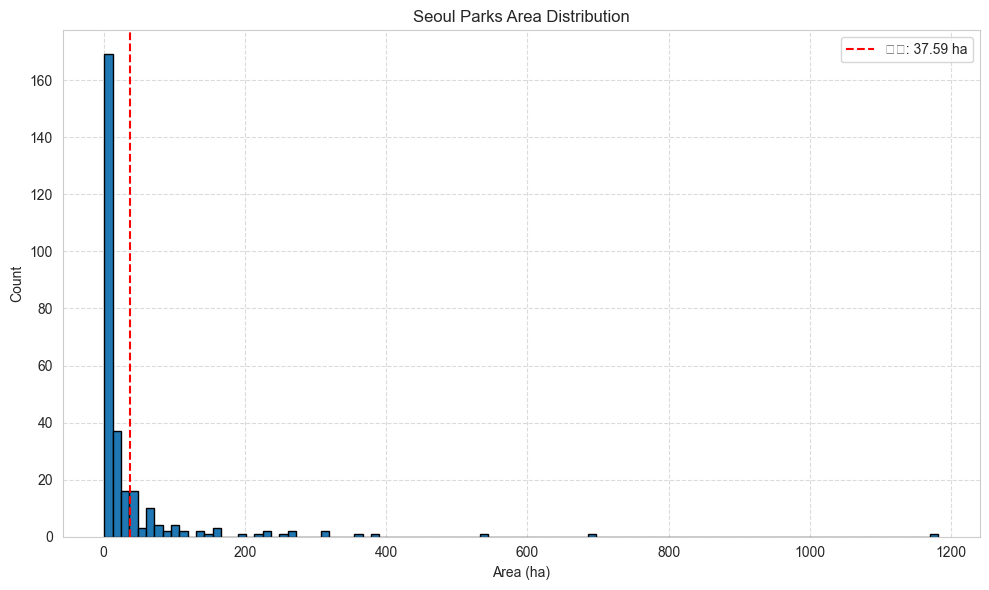

In [24]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 读取 shp 文件
shapefile_path = r'D:\seoul\Final_data\park\park_final_final.shp'
gdf = gpd.read_file(shapefile_path)

# 计算面积
gdf['area_sqm'] = gdf.geometry.area  # EPSG 坐标系需为米
gdf['area_m²'] = gdf['area_sqm']

# 使用完整 gdf
filtered_gdf = gdf

# 统计数据
max_area = filtered_gdf['area_m²'].max()
min_area = filtered_gdf['area_m²'].min()
mean_area = filtered_gdf['area_m²'].mean()
median_area = filtered_gdf['area_m²'].median()
std_area = filtered_gdf['area_m²'].std()
count = filtered_gdf.shape[0]

# 打印统计结果
print("===== Seoul Parks Area 统计数据（单位：m²）=====")
print(f"样本数量: {count}")
print(f"最大值: {max_area:.2f} m²")
print(f"最小值: {min_area:.2f} m²")
print(f"平均值: {mean_area:.2f} m²")
print(f"中位数: {median_area:.2f} m²")
print(f"标准差: {std_area:.2f} m²")

# 绘制直方图（横坐标单位：公顷）
plt.figure(figsize=(10, 6))
plt.hist(filtered_gdf['area_m²'] / 10000, bins=100, edgecolor='black')  # 换算为 hectares
plt.title('Seoul Parks Area Distribution')
plt.xlabel('Area (ha)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.7)

# 平均线
plt.axvline(mean_area / 10000, color='red', linestyle='dashed', linewidth=1.5, label=f'平均: {mean_area/10000:.2f} ha')
plt.legend()

plt.tight_layout()
plt.show()


# 02 distance to water bodies
# 02 waterbody ratio

In [25]:
# *** 01_02 替代算法，需要统计census tract中心点到绿地的最近值

import geopandas as gpd
from shapely.geometry import Point

def calculate_min_distance_to_parks(park_shp_path, census_shp_path, output_path):
    parks_gdf = gpd.read_afile(park_shp_path)
    census_gdf = gpd.read_file(census_shp_path)

    # ✅ 投影一致性：转换为 UTM 等以米为单位的投影
    parks_crs = parks_gdf.crs
    census_gdf = census_gdf.to_crs(parks_crs)

    # ✅ calculate the centroid
    census_gdf = census_gdf.copy()
    census_gdf['centroid'] = census_gdf.geometry.centroid

    # ✅ calculate the distance from the point to the centroid
    distances = [parks_gdf.distance(pt).min() for pt in census_gdf['centroid']]
    census_gdf['Dist_BP'] = distances

    # ✅ 删除临时列
    census_gdf.drop(columns=['centroid'], inplace=True)

    # ✅ 坐标系换回原始
    original_crs = gpd.read_file(census_shp_path).crs
    census_gdf = census_gdf.to_crs(original_crs)

    # ✅ 保存
    census_gdf.to_file(output_path)
    print(f"✅ 已保存: {output_path}")


# 示例调用
park_shp =  r'D:\seoul\Final_data\park\seoul_large_park.shp'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_distbp.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        calculate_min_distance_to_parks(park_shp, input_path, output_path)

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_distbp.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_dist

In [26]:
import geopandas as gpd
from shapely.geometry import Point

def calculate_min_distance_to_mountain(park_shp_path, census_shp_path, output_path):
    parks_gdf = gpd.read_file(park_shp_path)
    census_gdf = gpd.read_file(census_shp_path)

    # ✅ 投影一致性：转换为 UTM 等以米为单位的投影
    parks_crs = parks_gdf.crs
    census_gdf = census_gdf.to_crs(parks_crs)

    # ✅ 计算中心点
    census_gdf = census_gdf.copy()
    census_gdf['centroid'] = census_gdf.geometry.centroid

    distances = [parks_gdf.distance(pt).min() for pt in census_gdf['centroid']]
    census_gdf['Dist_MT'] = distances

    # ✅ 删除临时列
    census_gdf.drop(columns=['centroid'], inplace=True)

    # ✅ 坐标系换回原始
    original_crs = gpd.read_file(census_shp_path).crs
    census_gdf = census_gdf.to_crs(original_crs)

    # ✅ 保存
    census_gdf.to_file(output_path)
    print(f"✅ 已保存: {output_path}")


# 示例调用
park_shp =  r'D:\seoul\Final_data\mountain\mountain_final.shp'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_distmt.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        calculate_min_distance_to_mountain(park_shp, input_path, output_path)

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp
✅ 已保存: D:\seo

In [27]:
import geopandas as gpd
from shapely.geometry import Point

def calculate_min_distance_to_waterbodies(park_shp_path, census_shp_path, output_path):
    parks_gdf = gpd.read_file(park_shp_path)
    census_gdf = gpd.read_file(census_shp_path)

    # ✅ 投影一致性：转换为 UTM 等以米为单位的投影
    parks_crs = parks_gdf.crs
    census_gdf = census_gdf.to_crs(parks_crs)

    # ✅ 计算中心点
    census_gdf = census_gdf.copy()
    census_gdf['centroid'] = census_gdf.geometry.centroid

    distances = [parks_gdf.distance(pt).min() for pt in census_gdf['centroid']]
    census_gdf['Dist_WB'] = distances

    # ✅ 删除临时列
    census_gdf.drop(columns=['centroid'], inplace=True)

    # ✅ 坐标系换回原始
    original_crs = gpd.read_file(census_shp_path).crs
    census_gdf = census_gdf.to_crs(original_crs)

    # ✅ 保存
    census_gdf.to_file(output_path)
    print(f"✅ 已保存: {output_path}")


# 示例调用
park_shp =  r'D:\seoul\Final_data\stream\seoul_stream_final.shp'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder
os.makedirs(output_folder, exist_ok=True)

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_distwb.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        calculate_min_distance_to_waterbodies(park_shp, input_path, output_path)

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
✅ 已保存: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_rati

# waterbody_ratio

In [28]:
from shapely.geometry import Point
import geopandas as gpd
import os

def calculate_waterbody_ratio(waterbody_shp_path, grid_shp_path, output_path):
    # 读取水体 shapefile
    water_gdf = gpd.read_file(waterbody_shp_path)

    # 读取网格 shapefile
    grid_gdf = gpd.read_file(grid_shp_path)

    # 坐标系统一
    target_crs = grid_gdf.crs
    water_gdf = water_gdf.to_crs(target_crs)

    # 创建新列 WR 初始为 0
    grid_gdf['WR(%)'] = 0.0

    # 遍历每个格子，计算水体与格子的交集面积
    for idx, row in grid_gdf.iterrows():
        grid_geom = row.geometry
        intersected_water = water_gdf[water_gdf.intersects(grid_geom)]

        if not intersected_water.empty:
            clipped = gpd.overlay(intersected_water, gpd.GeoDataFrame(geometry=[grid_geom], crs=target_crs), how='intersection')
            water_area = clipped.geometry.area.sum()
            total_area = grid_geom.area
            wr_ratio = (water_area / total_area) * 100 if total_area > 0 else 0
            grid_gdf.at[idx, 'WR(%)'] = wr_ratio

    # 保存结果
    grid_gdf.to_file(output_path)
    print(f"✅ WR 已保存到: {output_path}")

waterbody_shp = r'D:\seoul\Final_data\stream\seoul_stream_final.shp'
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_wr.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        calculate_waterbody_ratio(waterbody_shp, input_path, output_path)

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
✅ WR 已保存到: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
✅ WR 已保存到: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
✅ WR 已保存到: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
✅ WR 已保存到: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
✅ WR 已保存到: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp
⏩ 已

# 增加一个代码，记录每个grid的中心点坐标

In [29]:
import os
import geopandas as gpd

grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr.shp'):
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(output_folder, filename.replace('.shp', '_xy.shp'))
        if os.path.exists(output_path):
            print(f"⏩ 已存在，跳过: {output_path}")
            pass
        # 读取 shapefile
        gdf = gpd.read_file(input_path)

        # 计算每个要素的中心点坐标
        centroids = gdf.geometry.centroid
        gdf['X'] = centroids.x
        gdf['Y'] = centroids.y

        # 保存新的 shapefile
        gdf.to_file(output_path)
        print(f"✅ 中心点坐标已写入: {output_path}")

⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✅ 中心点坐标已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✅ 中心点坐标已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✅ 中心点坐标已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
⏩ 已存在，跳过: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✅ 中心点坐标已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp
✅ 中心点坐标已写入: D:\seoul\grids\lst_map\city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_di

# ***********很重要 出图用的 但是得先有xy的结果

In [30]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# 输出文件夹
output_folder = r'D:\seoul\grids\lst_map\figures\grids_colored'
os.makedirs(output_folder, exist_ok=True)

# 你想要可视化的字段（可改成其他字段）
#value_column = 'nor_2020'  # 改成 'SVF'、'NDVI'、'WR(%)' 也行
explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)',
                    'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']

for value_column in explanatory_vars:
    # 循环读取不同网格大小的 shapefile 并绘制
    for i in grid_sizes: #range(120,1200,120):
        shp_path = rf'D:\seoul\grids\lst_map\city2020_lst_ratio_grid_{i}m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'

        if not os.path.exists(shp_path):
            print(f"❌ 文件不存在：{shp_path}")
            continue

        gdf = gpd.read_file(shp_path)

        if value_column not in gdf.columns:
            print(f"⚠️ {value_column} 不存在于 {i}m 数据中，跳过")
            continue

        # 画图
        fig, ax = plt.subplots(figsize=(8, 8))
        gdf.plot(column=value_column,
                 ax=ax,
                 cmap='RdYlBu_r',     # 可改成 'RdYlBu_r' 等色带
                 linewidth=0.2,
                 edgecolor='gray',
                 legend=True)

        ax.set_title(f'{value_column} (Grid: {i}m)', fontsize=14)
        ax.axis('off')

        output_path = os.path.join(output_folder, f'{value_column}_{i}m_map.png')
        plt.savefig(output_path, dpi=300, bbox_inches='tight')
        plt.close()
        print(f"✅ Saved: {output_path}")


✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_360m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_480m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_600m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_720m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_840m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_960m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_1080m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BCR(%)_450m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BHV_120m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BHV_240m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_colored\BHV_360m_map.png
✅ Saved: D:\seoul\grids\lst_map\figures\grids_

# Descriptive statistics

In [1]:
import os
import re
import pandas as pd
import geopandas as gpd
grid_folder = r'D:\seoul\grids\lst_map'
output_folder = grid_folder

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        input_path = os.path.join(grid_folder, filename)
        data = gpd.read_file(input_path)
        #print(data)
        print("列名如下：")
        print(list(data.columns))


grid_folder = r'D:\seoul\grids\lst_map'
output_path = os.path.join(grid_folder, 'Descriptive statistics.xlsx')

all_stats = []

for filename in os.listdir(grid_folder):
    if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp'):
        input_path = os.path.join(grid_folder, filename)
        df = gpd.read_file(input_path)

        raw_columns = ['nor_2020', 'ext_2020', 'hr_2020', 'BHV','BCR(%)', 'SVF', 'NDVI', 'EV(m)', 'WR(%)', 'Dist_BP', 'Dist_WB', 'Dist_MT']
        output_labels = ['Regular_LST(℃)', 'Extreme_LST(℃)', 'HR_T(℃)', 'BHF', 'BCR(%)', 'SVF', 'NDVI', 'EV(m)', 'WR(%)', 'Near_P(m)', 'Near_S(m)', 'Near_M(m)']

        desc = df[raw_columns].describe().T[['mean', 'min', 'max', 'std']]
        desc.columns = ['Mean', 'Min', 'Max', 'SD']
        desc.index = output_labels
        desc = desc.round(2)

        # ✅ 用正则表达式提取 "{grid}"m
        match = re.search(r'(\d{3,5})m', filename)
        grid_id = match.group(1) if match else 'Unknown'

        desc['Grid'] = grid_id  # 添加 Grid 列（如 1080）
        all_stats.append(desc.reset_index())

# 合并所有结果
summary_df = pd.concat(all_stats, ignore_index=True)
summary_df.rename(columns={'index': 'Variable'}, inplace=True)

# 输出 Excel
summary_df.to_excel(output_path, index=False)
print(f"📁 描述性统计合并完成！保存路径：{output_path}")

列名如下：
['UFID', 'BJCD', 'NAME', 'DIVI', 'SCLS', 'FMTA', 'Shape_Area', 'city_id', 'lst', 'lst_ratio', 'nor_2020', 'ext_2020', 'hr_2020', 'grid_id', 'BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)', 'X', 'Y', 'geometry']
列名如下：
['UFID', 'BJCD', 'NAME', 'DIVI', 'SCLS', 'FMTA', 'Shape_Area', 'city_id', 'lst', 'lst_ratio', 'nor_2020', 'ext_2020', 'hr_2020', 'grid_id', 'BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)', 'X', 'Y', 'geometry']
列名如下：
['UFID', 'BJCD', 'NAME', 'DIVI', 'SCLS', 'FMTA', 'Shape_Area', 'city_id', 'lst', 'lst_ratio', 'nor_2020', 'ext_2020', 'hr_2020', 'grid_id', 'BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)', 'X', 'Y', 'geometry']
列名如下：
['UFID', 'BJCD', 'NAME', 'DIVI', 'SCLS', 'FMTA', 'Shape_Area', 'city_id', 'lst', 'lst_ratio', 'nor_2020', 'ext_2020', 'hr_2020', 'grid_id', 'BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)', 'X', 'Y', 'geometr

In [33]:
import geopandas as gpd
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
import seaborn as sns

# 📁 设置路径
grid_folder = r'D:\seoul\grids\lst_map'
fig_output = os.path.join(grid_folder, 'figures', 'boxplot_from_raw')
os.makedirs(fig_output, exist_ok=True)

# 📊 你要分析的字段
raw_columns = ['nor_2020', 'ext_2020', 'hr_2020', 'BHV', 'BCR(%)', 'SVF',
               'NDVI', 'EV(m)', 'WR(%)', 'Dist_BP', 'Dist_WB', 'Dist_MT']

# 变量显示名称（用于图上）
column_labels = {
    'nor_2020': 'Regular_LST(℃)',
    'ext_2020': 'Extreme_LST(℃)',
    'hr_2020': 'HR_T(℃)',
    'BHV': 'BHV',
    'BCR(%)': 'BCR(%)',
    'SVF': 'SVF',
    'NDVI': 'NDVI',
    'EV(m)': 'EV(m)',
    'WR(%)': 'WR(%)',
    'Dist_BP': 'Near_P(m)',
    'Dist_WB': 'Near_S(m)',
    'Dist_MT': 'Near_M(m)'
}

# 🔄 合并所有 shp 文件原始数据
combined_data = []

for filename in os.listdir(grid_folder):
    if filename.endswith('_xy_clean.shp'):
        match = re.search(r'(\d{3,5})m', filename)
        grid_size = match.group(1) if match else 'unknown'
        input_path = os.path.join(grid_folder, filename)

        df = gpd.read_file(input_path)
        df = df[raw_columns].copy()
        df['Grid'] = int(grid_size)

        combined_data.append(df)

# 合并所有数据
full_df = pd.concat(combined_data, ignore_index=True)

# 📈 绘图：每个变量一张箱型图
for col in raw_columns:
    plt.figure(figsize=(6, 2))
    sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')

    plt.title(f'{column_labels[col]} by Grid Size', fontsize=13)
    plt.xlabel('Grid Size (m)')
    plt.ylabel(column_labels[col])
    plt.grid(True)
    plt.tight_layout()

    fig_path = os.path.join(fig_output, f'{col}_boxplot.png')
    plt.savefig(fig_path, dpi=300)
    plt.close()
    print(f"📦 已保存箱型图：{fig_path}")



C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:60: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:63: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.savefig(fig_path, dpi=300)


📦 已保存箱型图：D:\seoul\grids\lst_map\figures\boxplot_from_raw\nor_2020_boxplot.png


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:60: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:63: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.savefig(fig_path, dpi=300)


📦 已保存箱型图：D:\seoul\grids\lst_map\figures\boxplot_from_raw\ext_2020_boxplot.png


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:60: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:63: UserWarning: Glyph 8451 (\N{DEGREE CELSIUS}) missing from font(s) Arial.
  plt.savefig(fig_path, dpi=300)


...

📦 已保存箱型图：D:\seoul\grids\lst_map\figures\boxplot_from_raw\Dist_BP_boxplot.png


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')


📦 已保存箱型图：D:\seoul\grids\lst_map\figures\boxplot_from_raw\Dist_WB_boxplot.png


C:\Users\owner\AppData\Local\Temp\ipykernel_824\2598841847.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_df, x='Grid', y=col, palette='pastel')


📦 已保存箱型图：D:\seoul\grids\lst_map\figures\boxplot_from_raw\Dist_MT_boxplot.png


# 03 spatial regression model findout the relationship between X and Y

In [34]:
import geopandas as gpd
import numpy as np
import os

# 设置你的文件夹路径
grid_folder = r'D:\seoul\grids\lst_map'

# 要检查的数据列（目标变量 + 解释变量）
vars_to_check = ['nor_2020', 'ext_2020', 'hr_2020', 'BCR(%)', 'SVF',
                 'NDVI', 'EV(m)', 'WR(%)', 'Dist_BP', 'Dist_WB', 'Dist_MT']

# 遍历所有 .shp 文件
for filename in os.listdir(grid_folder):
    if filename.endswith('xy.shp') and '_clean' not in filename:
        input_path = os.path.join(grid_folder, filename)
        output_path = os.path.join(grid_folder, filename.replace('.shp', '_clean.shp'))

        try:
            gdf = gpd.read_file(input_path)

            # 替换 Inf 为 NaN
            gdf_clean = gdf.replace([np.inf, -np.inf], np.nan)

            # 删除含有 NaN 的行
            before = len(gdf)
            gdf_clean = gdf_clean.dropna(subset=vars_to_check)
            after = len(gdf_clean)

            # 保存新文件
            gdf_clean.to_file(output_path)
            print(f"✅ 已清理: {filename}  → 保留 {after}/{before} 行")
        except Exception as e:
            print(f"❌ 处理失败: {filename} - {str(e)}")

✅ 已清理: city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 609/612 行
✅ 已清理: city2020_lst_ratio_grid_120m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 42250/42948 行
✅ 已清理: city2020_lst_ratio_grid_240m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 10828/10958 行
✅ 已清理: city2020_lst_ratio_grid_360m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 4918/4962 行
✅ 已清理: city2020_lst_ratio_grid_450m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 3192/3229 行
✅ 已清理: city2020_lst_ratio_grid_480m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 2810/2837 行
✅ 已清理: city2020_lst_ratio_grid_600m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 1834/1851 行
✅ 已清理: city2020_lst_ratio_grid_720m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 1298/1308 行
✅ 已清理: city2020_lst_ratio_grid_840m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy.shp  → 保留 961/969 行
✅ 已清理: city2020_lst_ratio_grid_960m_bcr_bhv_ndvi_svf_e

In [ ]:
# import geopandas as gpd
# import statsmodels.api as sm
# import numpy as np
# import pandas as pd
# import os
# import re
#
# def run_ols_and_collect_with_se(shp_path, explanatory_vars, target_vars):
#     """
#     对一个 shapefile 执行 OLS 回归，返回系数、标准误差、p值、显著性标记等信息。
#     """
#     gdf = gpd.read_file(shp_path)
#     gdf = gdf.replace([np.inf, -np.inf], np.nan)
#     gdf = gdf.dropna(subset=explanatory_vars)
#
#     results = []
#     for y_var in target_vars:
#         X = gdf[explanatory_vars].copy()
#         y = gdf[y_var].copy()
#         combined = pd.concat([X, y], axis=1).dropna()
#
#         if combined.empty:
#             continue
#
#         X_clean = sm.add_constant(combined[explanatory_vars])
#         y_clean = combined[y_var]
#
#         model = sm.OLS(y_clean, X_clean).fit()
#
#         for var in ['const'] + explanatory_vars:
#             coef = model.params.get(var, np.nan)
#             std_err = model.bse.get(var, np.nan)
#             pval = model.pvalues.get(var, np.nan)
#
#             # 添加显著性星号
#             if pval < 0.001:
#                 sig = '***'
#             elif pval < 0.01:
#                 sig = '**'
#             elif pval < 0.05:
#                 sig = '*'
#             else:
#                 sig = ''
#
#             results.append({
#                 'Variable': var,
#                 'Target': y_var,
#                 'Coef': round(coef, 4),
#                 'StdErr': round(std_err, 4),
#                 'Pval': round(pval, 4),
#                 'Sig': sig,
#                 'R2': round(model.rsquared, 4),
#                 'Adj_R2': round(model.rsquared_adj, 4),
#                 'N': int(model.nobs)
#             })
#     return results
#
# def format_multilevel_columns_table(results):
#     """
#     正确生成列为 MultiIndex 的 DataFrame：
#     第一层是目标变量（如 nor_2020），第二层是 Coefficient / SD error
#     """
#     df = pd.DataFrame(results)
#     targets = df['Target'].unique()
#     variables = df['Variable'].unique()
#
#     rows = []
#
#     for var in variables:
#         row = [var]
#         for target in targets:
#             sub = df[(df['Variable'] == var) & (df['Target'] == target)]
#             if not sub.empty:
#                 coef = sub.iloc[0]['Coef']
#                 pval = sub.iloc[0]['Pval']
#                 sig = sub.iloc[0]['Sig']
#                 std_err = sub.iloc[0]['StdErr']
#             else:
#                 coef = np.nan
#                 pval = np.na
#                 sig = np.nan
#                 std_err = np.nan
#             row.extend([coef, pval, sig, std_err])
#         rows.append(row)
#
#     # 构造列名：MultiIndex
#     first_row = ['']
#     second_row = ['']
#
#     for target in targets:
#         first_row.extend([target, target, target, target])
#         second_row.extend(['Coefficient','P-value','Sig', 'SD error'])
#
#     multi_cols = pd.MultiIndex.from_arrays([first_row, second_row])
#     df_out = pd.DataFrame(rows, columns=multi_cols)
#
#     return df_out
#
# # === 🏁 主程序：批量处理多个 shapefile 并保存为 Excel ===
# grid_folder = r'D:\seoul\grids\lst_map'
# explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
# target_vars = ['nor_2020', 'ext_2020', 'hr_2020']
#
# all_results = []
#
# for filename in os.listdir(grid_folder):
#     if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
#         input_path = os.path.join(grid_folder, filename)
#
#         # 提取 grid size
#         match = re.search(r'(\d{3,5})m', filename)
#         grid_size = match.group(1) if match else 'unknown'
#
#         result_rows = run_ols_and_collect_with_se(input_path, explanatory_vars, target_vars)
#         for row in result_rows:
#             row['GridSize'] = grid_size
#         all_results.extend(result_rows)
# # 合并所有结果
# df_all = pd.DataFrame(all_results)
#
# # ✅ 保存详细长格式结果
# detailed_path = os.path.join(grid_folder, 'OLS_regression.xlsx')
# df_all.to_excel(detailed_path, index=False)
#
# # ✅ 保存发表格式（每个 GridSize 一个 sheet）
# publication_path = os.path.join(grid_folder, 'OLS_regression_final.xlsx')
# with pd.ExcelWriter(publication_path, engine='openpyxl') as writer:
#     for grid_size in sorted(df_all['GridSize'].unique()):
#         df_sub = df_all[df_all['GridSize'] == grid_size]
#         table = format_multilevel_columns_table(df_sub.to_dict('records'))
#         sheet_name = f"{grid_size}m"
#         table.to_excel(writer, sheet_name=sheet_name)
#
# print(f"\n✅ 所有 GridSize 的发表格式表格已保存：{publication_path}")

In [ ]:
# import geopandas as gpd
# import statsmodels.api as sm
# import numpy as np
# import pandas as pd
# import os
# import re
#
# def run_ols_and_collect_with_se(shp_path, explanatory_vars, target_vars):
#     """
#     对一个 shapefile 执行 OLS 回归，返回系数、标准误差、p值、显著性标记等信息。
#     """
#     gdf = gpd.read_file(shp_path)
#     gdf = gdf.replace([np.inf, -np.inf], np.nan)
#     gdf = gdf.dropna(subset=explanatory_vars)
#
#     results = []
#     for y_var in target_vars:
#         X = gdf[explanatory_vars].copy()
#         y = gdf[y_var].copy()
#         combined = pd.concat([X, y], axis=1).dropna()
#
#         if combined.empty:
#             continue
#
#         X_clean = sm.add_constant(combined[explanatory_vars])
#         y_clean = combined[y_var]
#
#         model = sm.OLS(y_clean, X_clean).fit()
#
#         for var in ['const'] + explanatory_vars:
#             coef = model.params.get(var, np.nan)
#             std_err = model.bse.get(var, np.nan)
#             pval = model.pvalues.get(var, np.nan)
#
#             # 添加显著性星号
#             if pval < 0.001:
#                 sig = '***'
#             elif pval < 0.01:
#                 sig = '**'
#             elif pval < 0.05:
#                 sig = '*'
#             else:
#                 sig = ''
#
#             results.append({
#                 'Variable': var,
#                 'Target': y_var,
#                 'Coef': round(coef, 4),
#                 'StdErr': round(std_err, 4),
#                 'Pval': round(pval, 4),
#                 'Sig': sig,
#                 'R2': round(model.rsquared, 4),
#                 'Adj_R2': round(model.rsquared_adj, 4),
#                 'N': int(model.nobs)
#             })
#     return results
#
# def format_multilevel_columns_table(results):
#     """
#     正确生成列为 MultiIndex 的 DataFrame：
#     第一层是目标变量（如 nor_2020），第二层是 Coefficient / SD error
#     """
#     df = pd.DataFrame(results)
#     targets = df['Target'].unique()
#     variables = df['Variable'].unique()
#
#     rows = []
#
#     for var in variables:
#         row = [var]
#         for target in targets:
#             sub = df[(df['Variable'] == var) & (df['Target'] == target)]
#             if not sub.empty:
#                 coef = round(sub.iloc[0]['Coef'], 2)
#                 sig = sub.iloc[0]['Sig']
#                 std_err = round(sub.iloc[0]['StdErr'], 2)
#
#             else:
#                 coef = np.nan
#                 sig = np.nan
#                 std_err = np.nan
#             row.extend([coef, sig, std_err])
#         rows.append(row)
#
#     # 构造列名：MultiIndex
#     first_row = ['']
#     second_row = ['']
#
#     for target in targets:
#         first_row.extend([target, target, target])
#         second_row.extend(['Coef.','Sig', 'SD error'])
#
#     multi_cols = pd.MultiIndex.from_arrays([first_row, second_row])
#     df_out = pd.DataFrame(rows, columns=multi_cols)
#
#     return df_out
#
# # === 🏁 主程序：批量处理多个 shapefile 并保存为 Excel ===
# grid_folder = r'D:\seoul\grids\lst_map'
# explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
# target_vars = ['nor_2020', 'ext_2020', 'hr_2020']
#
# all_results = []
#
# for filename in os.listdir(grid_folder):
#     if filename.endswith('_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp'):
#         input_path = os.path.join(grid_folder, filename)
#
#         # 提取 grid size
#         match = re.search(r'(\d{3,5})m', filename)
#         grid_size = match.group(1) if match else 'unknown'
#
#         result_rows = run_ols_and_collect_with_se(input_path, explanatory_vars, target_vars)
#         for row in result_rows:
#             row['GridSize'] = grid_size
#         all_results.extend(result_rows)
# # 合并所有结果
# df_all = pd.DataFrame(all_results)
#
# # ✅ 保存详细长格式结果
# detailed_path = os.path.join(grid_folder, 'OLS_regression.xlsx')
# df_all.to_excel(detailed_path, index=False)
#
# # ✅ 保存发表格式（每个 GridSize 一个 sheet）
# publication_path = os.path.join(grid_folder, 'OLS_regression_final.xlsx')
# with pd.ExcelWriter(publication_path, engine='openpyxl') as writer:
#     for grid_size in sorted(df_all['GridSize'].unique()):
#         df_sub = df_all[df_all['GridSize'] == grid_size]
#         table = format_multilevel_columns_table(df_sub.to_dict('records'))
#         sheet_name = f"{grid_size}m"
#         table.to_excel(writer, sheet_name=sheet_name)
#
# print(f"\n✅ 所有 GridSize 的发表格式表格已保存：{publication_path}")

# 03 做空间回归分析

In [ ]:
# !{sys.executable} -m pip install pysal esda libpysal geopandas

In [36]:
from libpysal.weights import Queen, KNN
from esda.moran import Moran
import geopandas as gpd
import numpy as np
# 3. 使用你已经做过的 OLS 回归计算残差（示例对 nor_2020）
import statsmodels.api as sm

# 1. 加载你的 shapefile
gdf = gpd.read_file(r'D:\seoul\grids\lst_map\city2020_lst_ratio_grid_1080m_bcr_bhv_ndvi_svf_ev_distbp_distmt_distwb_wr_xy_clean.shp')

# 2. 创建空间权重矩阵（Queen 邻接 或 KNN）
w = Queen.from_dataframe(gdf)  # 或：KNN.from_dataframe(gdf, k=4)
w.transform = 'r'  # row-standardized

explanatory_vars = ['BCR(%)', 'BHV', 'NDVI', 'SVF', 'EV(m)', 'Dist_BP', 'Dist_MT', 'Dist_WB', 'WR(%)']
# 构建自变量和因变量
X = gdf[explanatory_vars].copy()
y = gdf['hr_2020'].copy()
# 添加常数项用于截距
X = sm.add_constant(X)
# 拟合模型
model = sm.OLS(y, X).fit()
residuals = model.resid

# 4. 计算 Moran's I
mi = Moran(residuals, w)

# 5. 输出结果
print(f"Global Moran's I: {mi.I:.4f}")
print(f"p-value: {mi.p_sim:.4f} ({'显著' if mi.p_sim < 0.05 else '不显著'})")

Global Moran's I: 0.6664
p-value: 0.0010 (显著)


C:\Users\owner\AppData\Local\Temp\ipykernel_824\3082912082.py:12: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)  # 或：KNN.from_dataframe(gdf, k=4)


# GBDT

In [ ]:
# !{sys.executable} -m pip install scikit-learn pandas geopandas openpyxl
# !{sys.executable} -m pip install --upgrade scikit-learn
# !{sys.executable} -m pip install --upgrade pip

# random search cv

In [37]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

# 模型和参数空间
gbdt = GradientBoostingRegressor(random_state=0)
param_dist = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5],
    'subsample': [0.6, 0.8, 1.0]
}

# 设置搜索器
random_search = RandomizedSearchCV(
    estimator=gbdt,
    param_distributions=param_dist,
    n_iter=20,  # 抽 20 组组合
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)

# 拟合（X 为解释变量，y 为目标）
random_search.fit(X, y)

# 最佳模型和参数
best_model = random_search.best_estimator_
print("✅ 最佳参数:", random_search.best_params_)
print("✅ 最佳得分 (R2):", random_search.best_score_)


✅ 最佳参数: {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 5, 'max_depth': 3, 'learning_rate': 0.01}
✅ 最佳得分 (R2): 0.558461317602295
